# Fuel Prices vs Food Inflation — Analysis

This notebook merges the cleaned petrol, diesel, and CPI datasets and explores their relationship through visualization, correlation, lag analysis, and Granger causality testing.

## 1. Setup
Loading the three cleaned master datasets produced by notebooks 01-04.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

petrol_master = pd.read_csv("../data/processed/petrol_master.csv")
diesel_master = pd.read_csv("../data/processed/diesel_master.csv")
cpi_food_master = pd.read_csv("../data/processed/cpi_food_master.csv")

## 2. National-Level Merge

Petrol and diesel data are state-level (one row per state, one column per month). To compare them against CPI's national-only food index, we first collapse each fuel dataset to a single national average per month by taking the mean across all states.

In [3]:
monthly_petrol_avg = petrol_master.drop(columns="State").mean()

petrol_avg_df = pd.DataFrame({
    "month_label" : petrol_master.drop(columns="State").columns,
    "avg_petrol_price" : monthly_petrol_avg
})

petrol_avg_df

,month_label,avg_petrol_price
2023-11,2023-11,648.933552
2023-12,2023-12,671.858205
2024-01,2024-01,668.296551
2024-02,2024-02,679.364483
2024-03,2024-03,696.787227
2024-04,2024-04,701.244425
2024-05,2024-05,769.617031
2024-06,2024-06,750.172275
2024-07,2024-07,770.541884
2024-08,2024-08,830.455009


In [4]:
monthly_diesel_avg = diesel_master.drop(columns="State").mean()

diesel_avg_df = pd.DataFrame({
    "month_label" : diesel_master.drop(columns="State").columns,
    "avg_diesel_price" : monthly_diesel_avg
})

diesel_avg_df

,month_label,avg_diesel_price
2023-11,2023-11,1055.568921
2023-12,2023-12,1126.690782
2024-01,2024-01,1153.005989
2024-02,2024-02,1257.061079
2024-03,2024-03,1341.159191
2024-04,2024-04,1415.058963
2024-05,2024-05,1403.962012
2024-06,2024-06,1462.975227
2024-07,2024-07,1379.477459
2024-08,2024-08,1406.051350


In [5]:
merged_df = petrol_avg_df.merge(diesel_avg_df, on="month_label", how="outer") \
                            .merge(cpi_food_master, on="month_label", how="outer")
merged_df = merged_df.dropna()
merged_df.columns = ["months", "avg_petrol", "avg_diesel", "food_index"]


## 3. Fuel Prices vs Food Index Over Time (Dual Axis)

Petrol/diesel (₦) and the food index are on very different scales, so a single shared y-axis would make the food index line look flat. This chart uses a second y-axis (`twinx()`) so both scales can be read clearly on the same timeline.

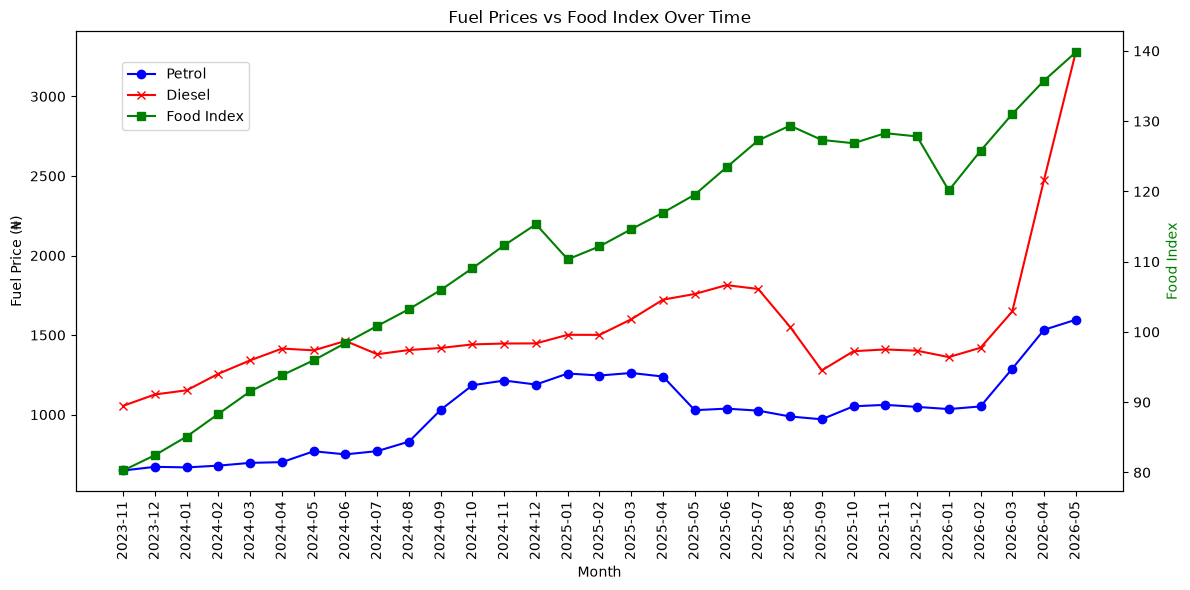

In [6]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(merged_df["months"], merged_df["avg_petrol"], color="blue", marker="o", label="Petrol")
ax1.plot(merged_df["months"], merged_df["avg_diesel"], color="red", marker="x", label="Diesel")
ax1.set_xlabel("Month")
ax1.set_ylabel("Fuel Price (₦)", color="black")
ax1.tick_params(axis="x", rotation=90)

ax2 = ax1.twinx()
ax2.plot(merged_df["months"], merged_df["food_index"], color="green", marker="s", label="Food Index")
ax2.set_ylabel("Food Index", color="green")

fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
plt.title("Fuel Prices vs Food Index Over Time")
plt.tight_layout()
plt.savefig("../data/processed/charts/fuel_vs_food_dualaxis.png")

plt.show()

## 4. Indexing to a Common Scale

To compare relative growth rather than raw price levels, each series is indexed to start at 100. This makes petrol, diesel, and food directly comparable on one shared axis, regardless of their original units.

In [7]:
merged_df["petrol_indexed"] = merged_df["avg_petrol"] / merged_df["avg_petrol"].iloc[0] * 100
merged_df["diesel_indexed"] = merged_df["avg_diesel"] / merged_df["avg_diesel"].iloc[0] * 100
merged_df["food_indexed"] = merged_df["food_index"] / merged_df["food_index"].iloc[0] * 100
merged_df

,months,avg_petrol,avg_diesel,food_index,petrol_indexed,diesel_indexed,food_indexed
0,2023-11,648.933552,1055.568921,80.280065,100.000000,100.000000,100.000000
1,2023-12,671.858205,1126.690782,82.465863,103.532666,106.737775,102.722716
2,2024-01,668.296551,1153.005989,85.114601,102.983818,109.230763,106.022088
3,2024-02,679.364483,1257.061079,88.340150,104.689376,119.088489,110.039958
4,2024-03,696.787227,1341.159191,91.534984,107.374203,127.055578,114.019569
5,2024-04,701.244425,1415.058963,93.827918,108.061052,134.056520,116.875737
6,2024-05,769.617031,1403.962012,95.971821,118.597201,133.005243,119.546268
7,2024-06,750.172275,1462.975227,98.418409,115.600784,138.595898,122.593834
8,2024-07,770.541884,1379.477459,100.851339,118.739720,130.685683,125.624386
9,2024-08,830.455009,1406.051350,103.241468,127.972272,133.203178,128.601625


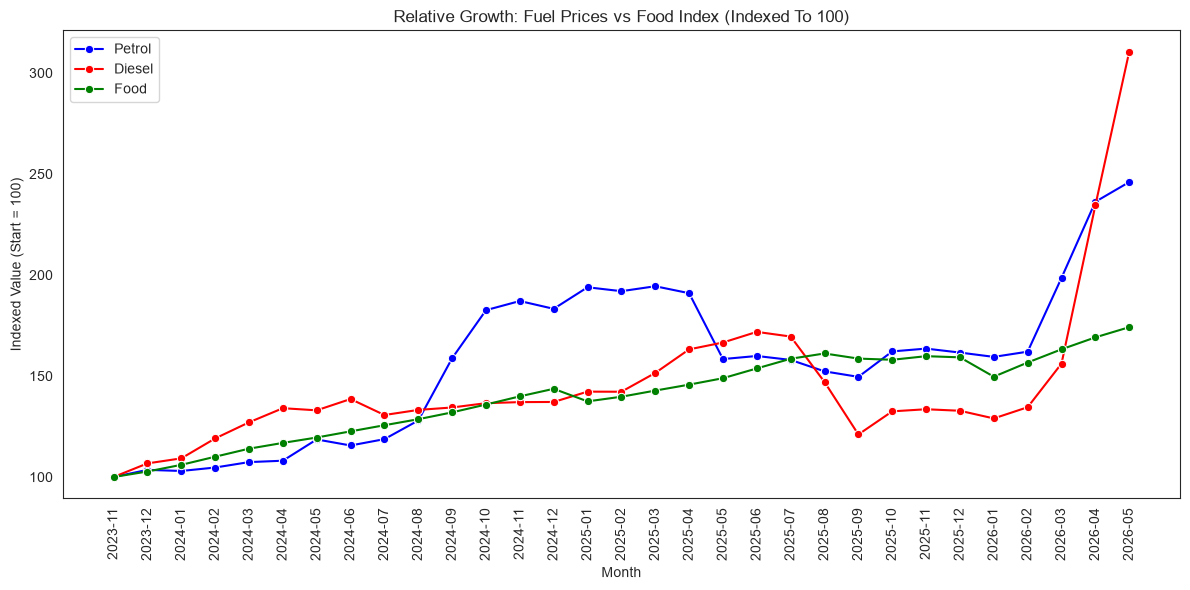

In [8]:
plt.figure(figsize=(12,6))

sns.set_style("white")
sns.lineplot(data=merged_df, x="months", y="petrol_indexed", color="blue", marker="o", label="Petrol")
sns.lineplot(data=merged_df, x="months", y="diesel_indexed", color="red", marker="o", label="Diesel")
sns.lineplot(data=merged_df, x="months", y="food_indexed", color="green", marker="o", label="Food")
plt.xticks(rotation=90)

plt.title("Relative Growth: Fuel Prices vs Food Index (Indexed To 100)")
plt.legend()
plt.xlabel("Month")
plt.ylabel("Indexed Value (Start = 100)")

plt.tight_layout()
plt.savefig("../data/processed/charts/fuel_vs_food_indexed.png")
plt.show()

## 5. Petrol Prices by State and Month (Heatmap)

A heatmap of the full state × month petrol grid, showing which states were consistently more or less expensive over the full time period.

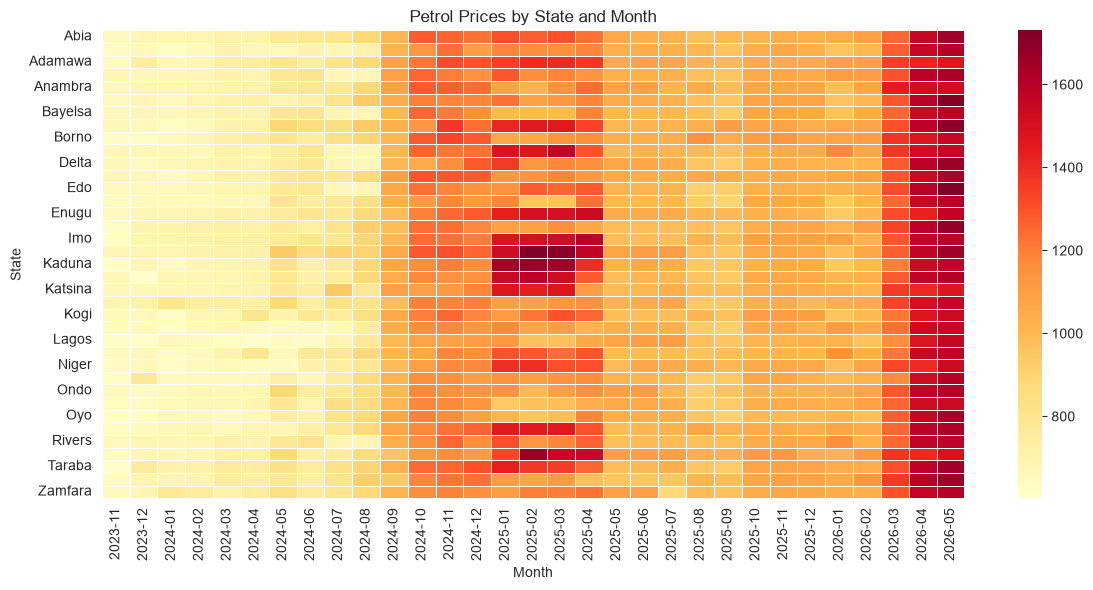

In [9]:
plt.figure(figsize=(12,6))

petrol_heatmap_data = petrol_master.set_index("State")
sns.heatmap(petrol_heatmap_data, cmap="YlOrRd", annot=False, linewidth=0.5)
plt.xticks(rotation=90)

plt.title("Petrol Prices by State and Month")
plt.xlabel("Month")
plt.ylabel("State")

plt.tight_layout()
plt.savefig("../data/processed/charts/petrol_heatmap_state_month.png")
plt.show()

## 6. Price Distribution Across States (Snapshot: July 2025)

A single-month snapshot showing how petrol prices were distributed across all states, to check for skew and spread.

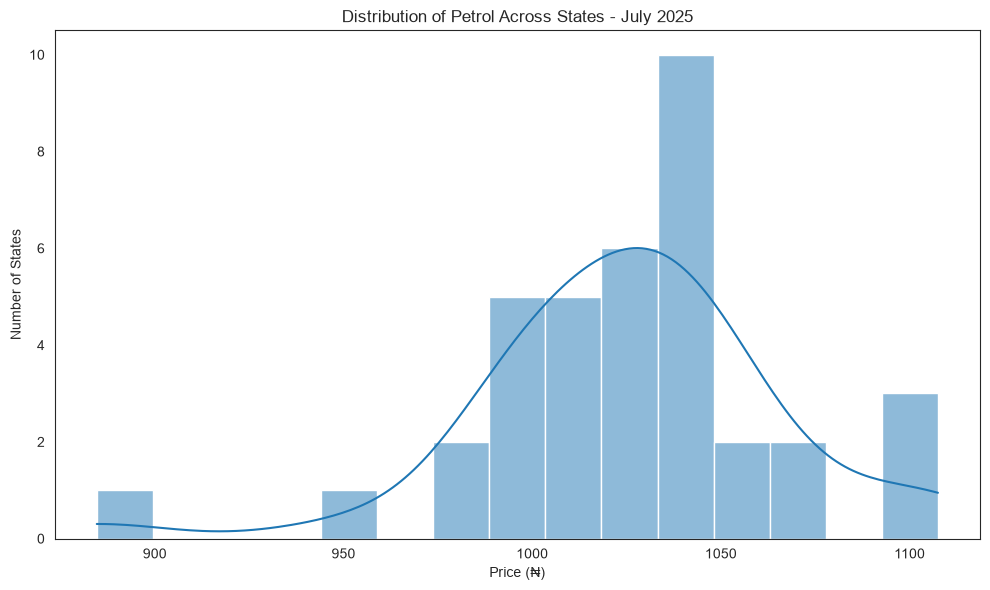

In [10]:
plt.figure(figsize=(10, 6))

sns.histplot(data=petrol_master, x="2025-07", kde=True, bins=15)

plt.title("Distribution of Petrol Across States - July 2025")
plt.xlabel("Price (₦)")
plt.ylabel("Number of States")

plt.tight_layout()
plt.savefig("../data/processed/charts/petrol_distribution_july2025.png")
plt.show()

## 7. Petrol vs Diesel Price Spread (Snapshot: July 2025)

A boxplot comparing petrol and diesel prices across states in the same month, to compare typical price level and variability between the two fuels.

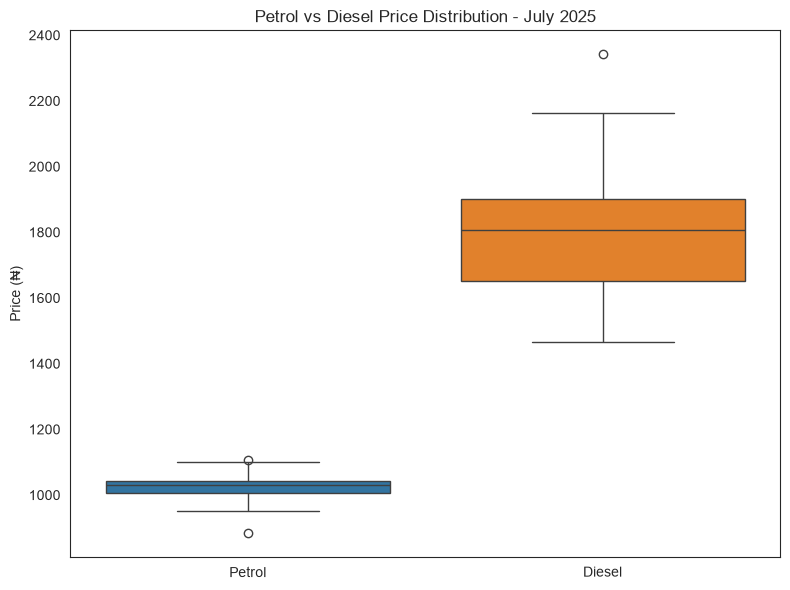

In [11]:
july_petrol_prices = petrol_master["2025-07"]
july_diesel_prices = diesel_master["2025-07"]

compare_df = pd.DataFrame({
    "Petrol" : july_petrol_prices,
    "Diesel" : july_diesel_prices
})

plt.figure(figsize=(8, 6))
sns.boxplot(data=compare_df)

plt.title("Petrol vs Diesel Price Distribution - July 2025")
plt.ylabel("Price (₦)")

plt.tight_layout()
plt.savefig("../data/processed/charts/petrol_vs_diesel_boxplot_july2025.png")
plt.show()


## 8. Price Variation Across States Over Time

Rather than a single-month snapshot, this tracks the standard deviation of prices across states for every month in the dataset, showing whether regional price disagreement has been growing or shrinking over time.

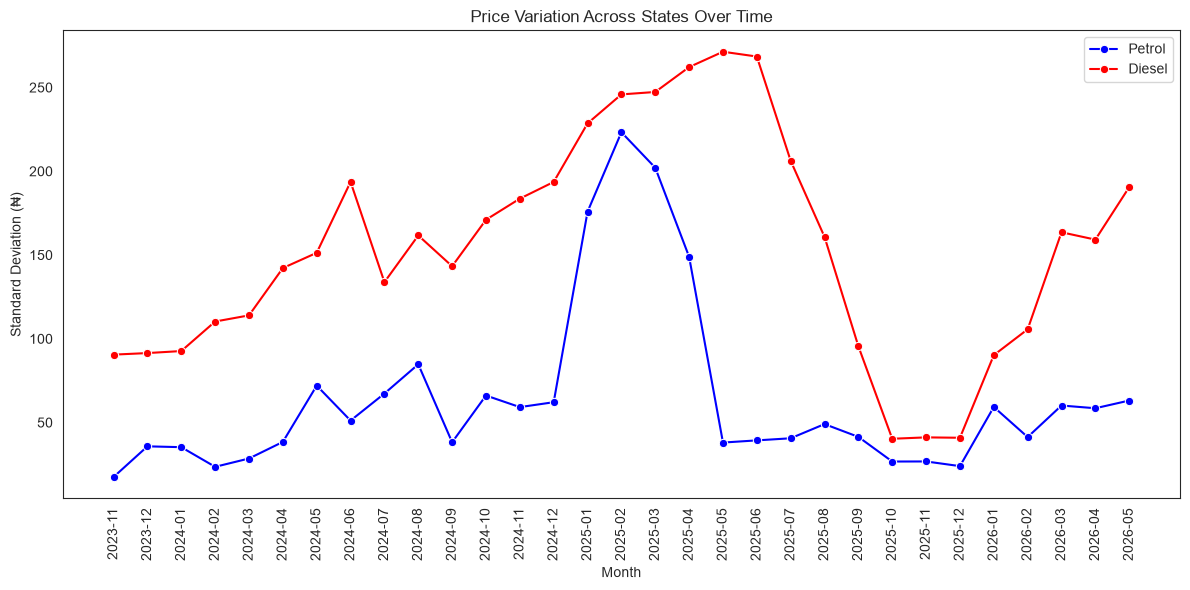

In [12]:
petrol_std = petrol_master.drop(columns="State").std()
diesel_std = diesel_master.drop(columns="State").std()

std_df = pd.DataFrame({
    "month" : petrol_std.index,
    "petrol_std" : petrol_std.values,
    "diesel_std" : diesel_std.values
})

plt.figure(figsize=(12, 6))
sns.lineplot(data=std_df, x="month", y="petrol_std", color="blue", marker="o", label="Petrol")
sns.lineplot(data=std_df, x="month", y="diesel_std", color="red", marker="o", label="Diesel")
plt.xticks(rotation=90)

plt.title("Price Variation Across States Over Time")
plt.xlabel("Month")
plt.ylabel("Standard Deviation (₦)")
plt.legend()

plt.tight_layout()
plt.savefig("../data/processed/charts/price_std_over_time.png")
plt.show()

## 9. Month-over-Month % Change

Calculating percentage change from the previous month for petrol, diesel, and food index, to see monthly volatility rather than the smoothed overall trend.

In [13]:
merged_df["petrol_pct_change"] = merged_df["avg_petrol"].pct_change() * 100
merged_df["diesel_pct_change"] = merged_df["avg_diesel"].pct_change() * 100
merged_df["food_pct_change"] = merged_df["food_index"].pct_change() * 100
merged_df

,months,avg_petrol,avg_diesel,food_index,petrol_indexed,diesel_indexed,food_indexed,petrol_pct_change,diesel_pct_change,food_pct_change
0,2023-11,648.933552,1055.568921,80.280065,100.000000,100.000000,100.000000,NaN,NaN,NaN
1,2023-12,671.858205,1126.690782,82.465863,103.532666,106.737775,102.722716,3.532666,6.737775,2.722716
2,2024-01,668.296551,1153.005989,85.114601,102.983818,109.230763,106.022088,-0.530120,2.335619,3.211921
3,2024-02,679.364483,1257.061079,88.340150,104.689376,119.088489,110.039958,1.656141,9.024679,3.789654
4,2024-03,696.787227,1341.159191,91.534984,107.374203,127.055578,114.019569,2.564565,6.690058,3.616515
5,2024-04,701.244425,1415.058963,93.827918,108.061052,134.056520,116.875737,0.639679,5.510142,2.504980
6,2024-05,769.617031,1403.962012,95.971821,118.597201,133.005243,119.546268,9.750182,-0.784204,2.284932
7,2024-06,750.172275,1462.975227,98.418409,115.600784,138.595898,122.593834,-2.526550,4.203334,2.549278
8,2024-07,770.541884,1379.477459,100.851339,118.739720,130.685683,125.624386,2.715324,-5.707395,2.472027
9,2024-08,830.455009,1406.051350,103.241468,127.972272,133.203178,128.601625,7.775453,1.926374,2.369953


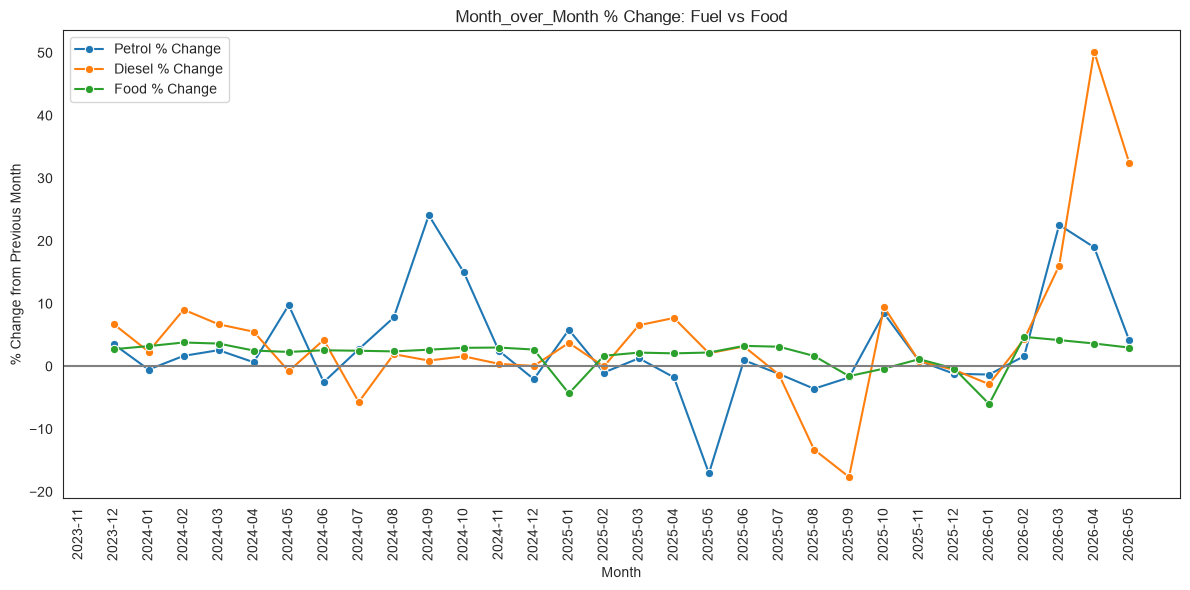

In [14]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=merged_df, x="months", y="petrol_pct_change", marker="o", label="Petrol % Change")
sns.lineplot(data=merged_df, x="months", y="diesel_pct_change", marker="o", label="Diesel % Change")
sns.lineplot(data=merged_df, x="months", y="food_pct_change", marker="o", label="Food % Change")
plt.axhline(0, color="gray", linestyle="-")
plt.xticks(rotation=90)

plt.title("Month_over_Month % Change: Fuel vs Food")
plt.legend()
plt.xlabel("Month")
plt.ylabel("% Change from Previous Month")

plt.tight_layout()
plt.savefig("../data/processed/charts/pct_change_over_time.png")
plt.show()

## 10. Rolling Average (Smoothed Trend)

A 3-month rolling average overlaid on the raw indexed values, to separate the underlying trend from short-term noise.

In [15]:
merged_df["petrol_rolling"] = merged_df["petrol_indexed"].rolling(window=3).mean()
merged_df["diesel_rolling"] = merged_df["diesel_indexed"].rolling(window=3).mean()
merged_df["food_rolling"] = merged_df["food_indexed"].rolling(window=3).mean()
merged_df

,months,avg_petrol,avg_diesel,food_index,petrol_indexed,diesel_indexed,food_indexed,petrol_pct_change,diesel_pct_change,food_pct_change,petrol_rolling,diesel_rolling,food_rolling
0,2023-11,648.933552,1055.568921,80.280065,100.000000,100.000000,100.000000,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-12,671.858205,1126.690782,82.465863,103.532666,106.737775,102.722716,3.532666,6.737775,2.722716,NaN,NaN,NaN
2,2024-01,668.296551,1153.005989,85.114601,102.983818,109.230763,106.022088,-0.530120,2.335619,3.211921,102.172161,105.322846,102.914934
3,2024-02,679.364483,1257.061079,88.340150,104.689376,119.088489,110.039958,1.656141,9.024679,3.789654,103.735287,111.685676,106.261587
4,2024-03,696.787227,1341.159191,91.534984,107.374203,127.055578,114.019569,2.564565,6.690058,3.616515,105.015799,118.458277,110.027205
5,2024-04,701.244425,1415.058963,93.827918,108.061052,134.056520,116.875737,0.639679,5.510142,2.504980,106.708210,126.733529,113.645088
6,2024-05,769.617031,1403.962012,95.971821,118.597201,133.005243,119.546268,9.750182,-0.784204,2.284932,111.344152,131.372447,116.813858
7,2024-06,750.172275,1462.975227,98.418409,115.600784,138.595898,122.593834,-2.526550,4.203334,2.549278,114.086346,135.219220,119.671946
8,2024-07,770.541884,1379.477459,100.851339,118.739720,130.685683,125.624386,2.715324,-5.707395,2.472027,117.645902,134.095608,122.588163
9,2024-08,830.455009,1406.051350,103.241468,127.972272,133.203178,128.601625,7.775453,1.926374,2.369953,120.770925,134.161587,125.606615


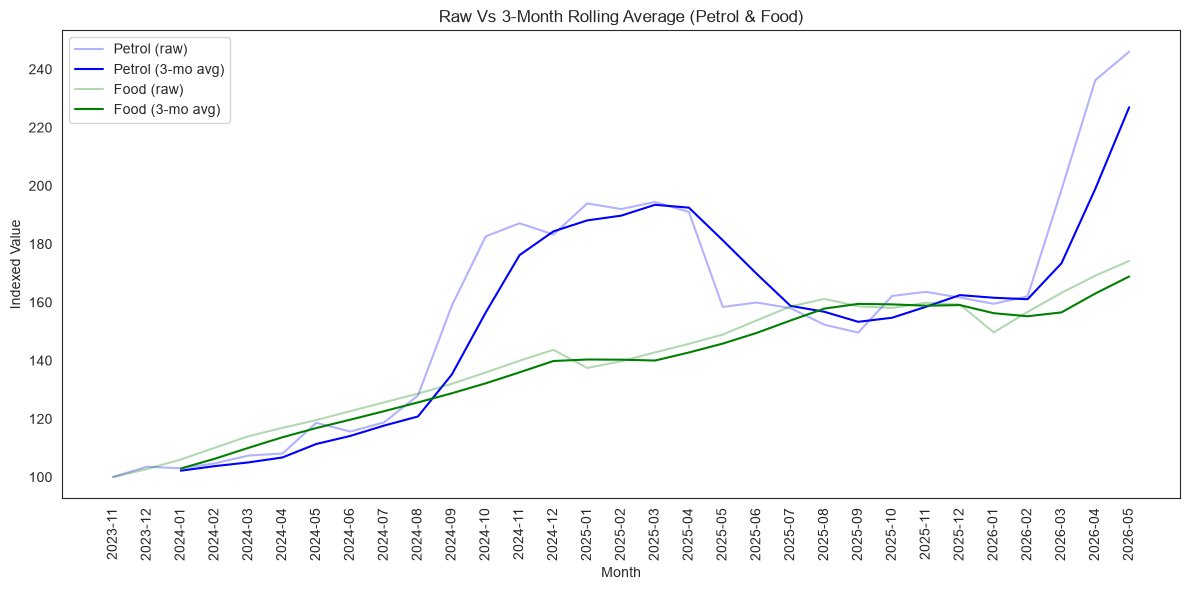

In [16]:
plt.figure(figsize=(12, 6))

sns.lineplot(data=merged_df, x="months", y="petrol_indexed", alpha=0.3, color="Blue", label="Petrol (raw)")
sns.lineplot(data=merged_df, x="months", y="petrol_rolling", color="Blue", label="Petrol (3-mo avg)")
sns.lineplot(data=merged_df, x="months", y="food_indexed", alpha=0.3, color="Green", label="Food (raw)")
sns.lineplot(data=merged_df, x="months", y="food_rolling", color="Green", label="Food (3-mo avg)")
plt.xticks(rotation=90)

plt.title("Raw Vs 3-Month Rolling Average (Petrol & Food)")
plt.legend()
plt.xlabel("Month")
plt.ylabel("Indexed Value")

plt.tight_layout()
plt.savefig("../data/processed/charts/rolling_avg_overlay.png")
plt.show()

## 11. Correlation: Fuel vs Food

Testing whether petrol/diesel prices and the food index move together, using Pearson correlation. The coefficient (r) measures strength of the relationship; the p-value indicates whether that relationship is statistically trustworthy or likely due to chance.

In [17]:
from scipy.stats import pearsonr

petrol_corr, petrol_p = pearsonr(merged_df["avg_petrol"], merged_df["food_index"])
diesel_corr, diesel_p = pearsonr(merged_df["avg_diesel"], merged_df["food_index"])

print(f"Petrol vs Food: correlation = {petrol_corr:.3f}, p-value = {petrol_p:.4f}")
print(f"Diesel vs Food: correlation = {diesel_corr:.3f}, p-value = {diesel_p:.4f}")

Petrol vs Food: correlation = 0.793, p-value = 0.0000
Diesel vs Food: correlation = 0.617, p-value = 0.0002


### Visualizing the Correlations

Scatter plots of each fuel against the food index, with the correlation coefficient shown in the title for direct visual comparison.

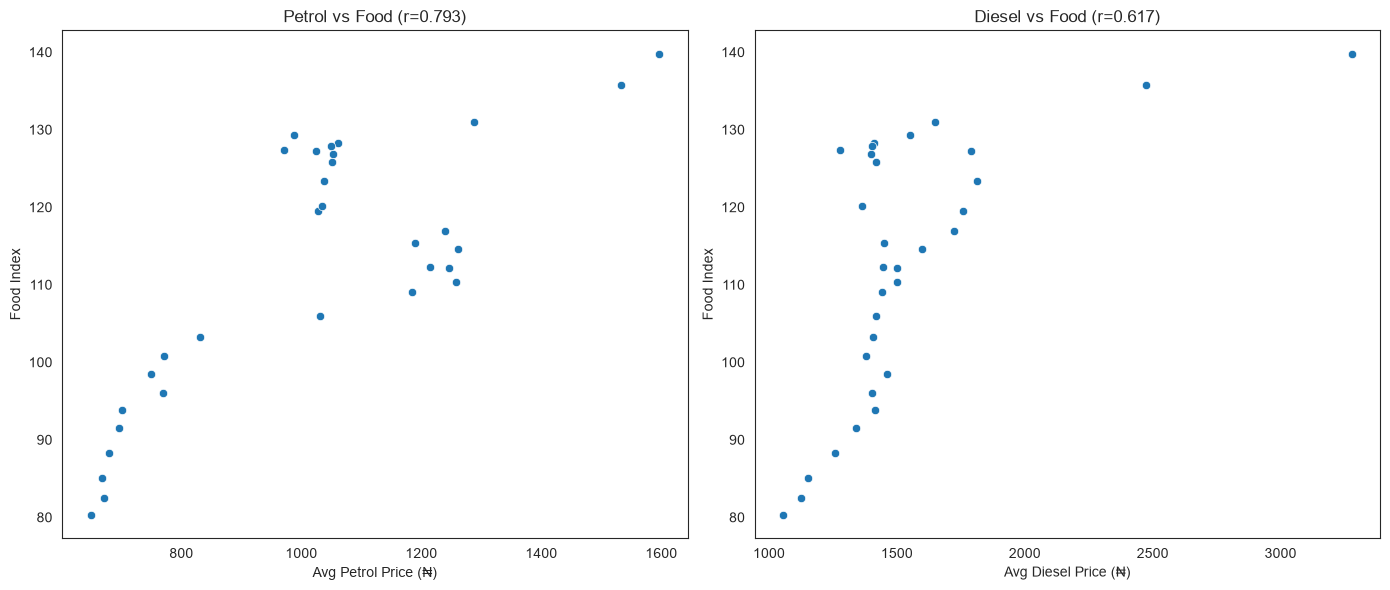

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(data=merged_df, x="avg_petrol", y="food_index", ax=axes[0])
axes[0].set_title(f"Petrol vs Food (r={petrol_corr:.3f})")
axes[0].set_xlabel("Avg Petrol Price (₦)")
axes[0].set_ylabel("Food Index")

sns.scatterplot(data=merged_df, x="avg_diesel", y="food_index", ax=axes[1])
axes[1].set_title(f"Diesel vs Food (r={diesel_corr:.3f})")
axes[1].set_xlabel("Avg Diesel Price (₦)")
axes[1].set_ylabel("Food Index")

plt.tight_layout()
plt.savefig("../data/processed/charts/scatter_correlations.png")
plt.show()

## 12. Lag Correlation

Testing whether fuel price changes precede food price changes (or vice versa) by shifting each series 1-3 months and re-checking correlation, to explore direction and timing of the relationship.

In [19]:
for lag in [1, 2, 3]:
    shifted_petrol = merged_df["avg_petrol"].shift(lag)
    valid = merged_df[["food_index"]].copy()
    valid["shifted_petrol"] = shifted_petrol
    valid = valid.dropna()

    corr, p = pearsonr(valid["shifted_petrol"], valid["food_index"])
    print(f"Petrol lag {lag} months -> Food: r={corr:.3f}, p={p:.4f}")

print()

for lag in [1, 2, 3]:
    shifted_diesel = merged_df["avg_diesel"].shift(lag)
    valid = merged_df[["food_index"]].copy()
    valid["shifted_diesel"] = shifted_diesel
    valid = valid.dropna()

    corr, p = pearsonr(valid["shifted_diesel"], valid["food_index"])
    print(f"Diesel lag {lag} months -> Food: r={corr:.3f}, p={p:.4f}")

Petrol lag 1 months -> Food: r=0.779, p=0.0000
Petrol lag 2 months -> Food: r=0.743, p=0.0000
Petrol lag 3 months -> Food: r=0.706, p=0.0000

Diesel lag 1 months -> Food: r=0.675, p=0.0000
Diesel lag 2 months -> Food: r=0.678, p=0.0001
Diesel lag 3 months -> Food: r=0.638, p=0.0003


In [25]:
for lag in [1, 2, 3]:
    shifted_food = merged_df["food_index"].shift(lag)
    valid = merged_df[["avg_petrol"]].copy()
    valid["shifted_food"] = shifted_food
    valid = valid.dropna()

    corr, p = pearsonr(valid["shifted_food"], valid["avg_petrol"])
    print(f"Food lag {lag} months -> Petrol: r={corr:.3f}, p={p:.4f}")

print()

for lag in [1, 2, 3]:
    shifted_food = merged_df["food_index"].shift(lag)
    valid = merged_df[["avg_diesel"]].copy()
    valid["shifted_food"] = shifted_food
    valid = valid.dropna()

    corr, p = pearsonr(valid["shifted_food"], valid["avg_diesel"])
    print(f"Food lag {lag} months -> Diesel: r={corr:.3f}, p={p:.4f}")

Food lag 1 months -> Petrol: r=0.751, p=0.0000
Food lag 2 months -> Petrol: r=0.693, p=0.0000
Food lag 3 months -> Petrol: r=0.642, p=0.0002

Food lag 1 months -> Diesel: r=0.531, p=0.0025
Food lag 2 months -> Diesel: r=0.429, p=0.0201
Food lag 3 months -> Diesel: r=0.330, p=0.0868


# 13. Granger Causality Testing

Correlation alone can't establish which variable leads the other. Granger causality tests whether past values of one series meaningfully improve prediction of another, beyond what that series' own past values already explain — a stricter test than simple correlation or lag correlation.

In [21]:
!python -m pip install statsmodels

from statsmodels.tsa.stattools import grangercausalitytests

In [22]:
test_data_petrol = merged_df[["food_index", "avg_petrol"]].dropna()
results_petrol = grangercausalitytests(test_data_petrol, maxlag=3)

test_data_petrol_reverse = merged_df[["avg_petrol", "food_index"]].dropna()
results_petrol_reverse = grangercausalitytests(test_data_petrol_reverse, maxlag=3)

In [23]:
test_data_diesel = merged_df[["food_index", "avg_diesel"]].dropna()
results_diesel = grangercausalitytests(test_data_diesel, maxlag=3)

test_data_diesel_reverse = merged_df[["avg_diesel", "food_index"]].dropna()
results_diesel_reverse = grangercausalitytests(test_data_diesel_reverse, maxlag=3)

### Reading the Results

Extracting the SSR F-test p-value for each lag (1-3 months), for all four direction/fuel combinations tested above

In [24]:
print("Petrol")
for lag in [1,2,3]:
    f_test = results_petrol[lag][0]["ssr_ftest"]
    print(f"Lag {lag}: F-stat = {f_test[0]:.3f}, p-value = {f_test[1]:.4f}")

print("\nReverse Petrol")
for lag in [1,2,3]:
    f_test = results_petrol_reverse[lag][0]["ssr_ftest"]
    print(f"Lag {lag}: F-stat = {f_test[0]:.3f}, p-value = {f_test[1]:.4f}")

print("\nDiesel")
for lag in [1,2,3]:
    f_test = results_diesel[lag][0]["ssr_ftest"]
    print(f"Lag {lag}: F-stat = {f_test[0]:.3f}, p-value = {f_test[1]:.4f}")

print("\nReverse Diesel")
for lag in [1,2,3]:
    f_test = results_diesel_reverse[lag][0]["ssr_ftest"]
    print(f"Lag {lag}: F-stat = {f_test[0]:.3f}, p-value = {f_test[1]:.4f}")


Petrol
Lag 1: F-stat = 1.108, p-value = 0.3019
Lag 2: F-stat = 0.947, p-value = 0.4019
Lag 3: F-stat = 0.982, p-value = 0.4201

Reverse Petrol
Lag 1: F-stat = 0.569, p-value = 0.4571
Lag 2: F-stat = 1.640, p-value = 0.2149
Lag 3: F-stat = 1.633, p-value = 0.2119

Diesel
Lag 1: F-stat = 4.251, p-value = 0.0490
Lag 2: F-stat = 1.843, p-value = 0.1800
Lag 3: F-stat = 1.959, p-value = 0.1511

Reverse Diesel
Lag 1: F-stat = 0.093, p-value = 0.7631
Lag 2: F-stat = 2.769, p-value = 0.0828
Lag 3: F-stat = 1.924, p-value = 0.1567


## Summary of Findings

**Descriptive stats:**
- Diesel avg: ₦ 1,537 | Petrol avg: ₦ 1,016 - diesel consistently more expensive and more valuable across states.
- Dataset: Nov 2023 - May 2026, 31 continuous months.
- Known data quirk: NBS changed "Nasarawa" to "Nassarawa" spelling in Oct 2025 - standardized in cleaning.

**Structural breaks to consider while interpreting trends**
- 2023 fuel subsidy removal
- 2024 CPI methodology rebase (new base year, pre/post not directly comparable)
- Feb - May 2025 Hormuz Strait disruption - sharp diesel/petrol spike (diesel + 86.4% YoY by May 2026)

**Correlation (same month)**
- Petrol vs Food: r=0.793, p=0.0000 (strong, highly significant)
- Diesel vs food: r=0.617, p=0.0002 (moderate-strong, significant)

**Lag correlation**
- Petrol: Food strongest at lag 1 (r=0.779) and same-month, weakeming at lag 2-3 
- Diesel: Food fairly stable across lags 1-3 (r=0.675, 0.678, 0.638)
- Food: Diesel weakens and loses significance by lag 3 (p=0.0868) - assymetric relationship

**Granger causality (stricter test)**
- Petrol ←→ Food: NOT significantly, either direction, any lag
- Diesel -→ Food: significant at lag 1 only (p=0.049) - short term predictive signal
- Food -→ Diesel: NOT significant, any lag

**Interpretation**
Petrol and food prices are strongly correlated, but this doesnt hold up under Granger causality - likely reflects shared macro drivers (inflation, currency devaluation) rather than direct causation. Diesel shows a narrow but real 1-month Granger-causal effect on food prices, plausibly explained by diesel's role in food transport/production(trucking, generators, irrigation) rather than diesel being directly consumed like petrol. This is a more specific, defensible finding rather than just a blanket "fuel drives food prices" claim.